## Here we are going to perform Titanic Classfication

In [119]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

### 1. Importing the data

### Column Descriptions

| Column Name    | Description |
|----------------|-------------|
| **PassengerId** | A unique ID for each passenger. Used for identification. |
| **Survived**    | Target variable. Indicates if the passenger survived (1) or died (0). |
| **Pclass**      | Ticket class of the passenger: <br>1 = 1st (Upper), 2 = 2nd (Middle), 3 = 3rd (Lower) class. |
| **Name**        | Full name of the passenger. May contain useful information (like title: Mr., Mrs., Miss). |
| **Sex**         | Gender of the passenger (`male` or `female`). |
| **Age**         | Age of the passenger in years. May contain missing values. |
| **SibSp**       | Number of siblings or spouses the passenger had aboard the Titanic. |
| **Parch**       | Number of parents or children the passenger had aboard the Titanic. |
| **Ticket**      | Ticket number. Can be useful but messy due to varying formats. |
| **Fare**        | Fare paid for the ticket. Correlated with `Pclass`. |
| **Cabin**       | Cabin number. Often contains missing values. Can be used to extract deck information. |
| **Embarked**    | Port of Embarkation: <br> C = Cherbourg, Q = Queenstown, S = Southampton. |


In [45]:
df = pd.read_csv("/Users/g.tarun/Downloads/tested.csv")

In [46]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


### 2. Data Analysis

In [47]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [49]:
# Lets create a function to display dataframe for the Unique Values, Total Values, Missing Values, Data Types
def data_analysis(data):
    unique_values = {}

    for column_name, column_values in data.items():
        unique_values[column_name] = {
            'Data Type' : column_values.dtype,
            'Total Values' : len(column_values),
            'Unique Values' : len(column_values.unique()),
            'Missing Values' : column_values.isna().sum()
        }

    df = pd.DataFrame.from_dict(unique_values, orient='index')
    return df

data_analysis(df)

,Data Type,Total Values,Unique Values,Missing Values
PassengerId,int64,418,418,0
Survived,int64,418,2,0
Pclass,int64,418,3,0
Name,object,418,418,0
Sex,object,418,2,0
Age,float64,418,80,86
SibSp,int64,418,7,0
Parch,int64,418,8,0
Ticket,object,418,363,0
Fare,float64,418,170,1


In [50]:
data.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
count,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,1.630000e+02,163.000000,163.0,163.000000,163.000000,163.000000
mean,1105.944785,0.269939,2.828221,0.269939,25.647239,0.147239,0.042945,2.523351e+05,9.322137,0.0,0.582822,1.190184,0.858896
std,116.975636,0.445296,0.378351,0.445296,3.118014,0.419187,0.256993,4.249123e+05,2.707993,0.0,0.822642,0.515825,0.349202
min,895.000000,0.000000,2.000000,0.000000,18.500000,0.000000,0.000000,0.000000e+00,6.437500,0.0,0.000000,1.000000,0.000000
25%,1001.500000,0.000000,3.000000,0.000000,23.000000,0.000000,0.000000,2.660500e+03,7.750000,0.0,0.000000,1.000000,1.000000
50%,1113.000000,0.000000,3.000000,0.000000,27.000000,0.000000,0.000000,3.150920e+05,7.895800,0.0,0.000000,1.000000,1.000000
75%,1203.500000,1.000000,3.000000,1.000000,27.000000,0.000000,0.000000,3.495825e+05,10.500000,0.0,1.000000,1.000000,1.000000
max,1308.000000,1.000000,3.000000,1.000000,32.500000,3.000000,2.000000,3.101298e+06,18.000000,0.0,2.000000,4.000000,1.000000


### Data Pre-Processing

#### There are 2 thing we have to tackel before we procced to the training

* The strings has to convert to the integers.
* We have to fill the missing value.

> objects present in the dataset are `Name, Sex, Ticket, Cabin, Embarked`

In [51]:
# let's make a copy of the original dataset to avoid modifying the original.
data = df.copy()

In [52]:
# checking weather there are any duplicate rows in the data.
print("\nDuplicate rows:", data.duplicated().sum())


Duplicate rows: 0


In [53]:
# first let's convert the sex
data['Sex'] = data['Sex'].map({'female': 1, 'male': 0})

In [54]:
# now let's convert the Embarked.
embarked_mapping = {'S': 0, 'C': 1, 'Q': 2}
data['Embarked'] = data['Embarked'].map(embarked_mapping)

In [55]:
# lets drop the Name form the dataset(because the name doesn't matter weather he will survive or not, and also they all are unique values)
data.drop(['Name', ], axis=1, inplace=True)

In [56]:
# Convert 'Ticket' to integers
data['Ticket'] = pd.to_numeric(data['Ticket'], errors='coerce').fillna(0).astype(int)

# For 'Cabin', fill NaNs with a placeholder and extract numeric part if possible
data['Cabin'] = data['Cabin'].fillna('Unknown')

# Map unique cabin values to integers (label encoding style)
cabin_mapping = {val: idx for idx, val in enumerate(data['Cabin'].unique())}
data['Cabin'] = df['Cabin'].map(cabin_mapping)

In [57]:
data_analysis(data)

,Data Type,Total Values,Unique Values,Missing Values
PassengerId,int64,418,418,0
Survived,int64,418,2,0
Pclass,int64,418,3,0
Sex,int64,418,2,0
Age,float64,418,80,86
SibSp,int64,418,7,0
Parch,int64,418,8,0
Ticket,int64,418,266,0
Fare,float64,418,170,1
Cabin,float64,418,77,327


In [65]:
# Filling the missing value in the dataset.
# let's fill the missing value with the median of the column.
data['Cabin'] = data['Cabin'].fillna(data['Cabin'].median())
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

In [66]:
data_analysis(data)

,Data Type,Total Values,Unique Values,Missing Values
PassengerId,int64,418,418,0
Survived,int64,418,2,0
Pclass,int64,418,3,0
Sex,int64,418,2,0
Age,float64,418,79,0
SibSp,int64,418,7,0
Parch,int64,418,8,0
Ticket,int64,418,266,0
Fare,float64,418,169,0
Cabin,float64,418,76,0


### Feature Engineering

In [67]:
# Create a family size feature
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [68]:
# Create is_alone feature
data['IsAlone'] = 0
data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

In [69]:
data_analysis(data)

,Data Type,Total Values,Unique Values,Missing Values
PassengerId,int64,418,418,0
Survived,int64,418,2,0
Pclass,int64,418,3,0
Sex,int64,418,2,0
Age,float64,418,79,0
SibSp,int64,418,7,0
Parch,int64,418,8,0
Ticket,int64,418,266,0
Fare,float64,418,169,0
Cabin,float64,418,76,0


### Handle outliers

In [71]:
# Select numeric columns to apply outlier removal
numeric_cols = ['Age', 'Fare', 'Cabin']

# Remove outliers using the IQR method
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3.5 * IQR
    upper_bound = Q3 + 3.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Display the shape of the dataset after outlier removal
data.shape

(317, 13)

In [72]:
data_analysis(data)

,Data Type,Total Values,Unique Values,Missing Values
PassengerId,int64,317,317,0
Survived,int64,317,2,0
Pclass,int64,317,3,0
Sex,int64,317,2,0
Age,float64,317,66,0
SibSp,int64,317,7,0
Parch,int64,317,8,0
Ticket,int64,317,216,0
Fare,float64,317,117,0
Cabin,float64,317,1,0


### Now we can split the data into the training and testing

In [74]:
x = data.drop('Survived', axis = 1)
y = data['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [76]:
# verifiy the size of the data
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((221, 12), (221,), (96, 12), (96,))

### I am planning to use `Decision Tree, Random forest, XGBoost`

### 1. XGBoost

In [87]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [90]:
# 1. Train with default parameters
xgb_default = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_default.fit(x_train, y_train)
xgb_default_pred = xgb_default.predict(x_test)
xgb_default_acc = accuracy_score(y_test, xgb_default_pred)

/Users/g.tarun/Downloads/ML_Projects/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [21:49:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [91]:
# 2. Train with hyperparameter tuning
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, n_jobs=-1, verbose=1)
xgb_grid.fit(x_train, y_train)
xgb_best = xgb_grid.best_estimator_
xgb_tuned_pred = xgb_best.predict(x_test)
xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/Users/g.tarun/Downloads/ML_Projects/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [21:49:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/g.tarun/Downloads/ML_Projects/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [21:49:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/g.tarun/Downloads/ML_Projects/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [21:49:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/g.tarun/Downloads/ML_Projects/env/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [21:49:55] WARNING: /Users/runner/work/xgboost/xgboost/

In [93]:
print("XGBoost Accuracy (Before Tuning):", xgb_default_acc)
print("XGBoost Accuracy (After Tuning):", xgb_tuned_acc)
print("Best Parameters:", xgb_grid.best_params_)

XGBoost Accuracy (Before Tuning): 1.0
XGBoost Accuracy (After Tuning): 1.0
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


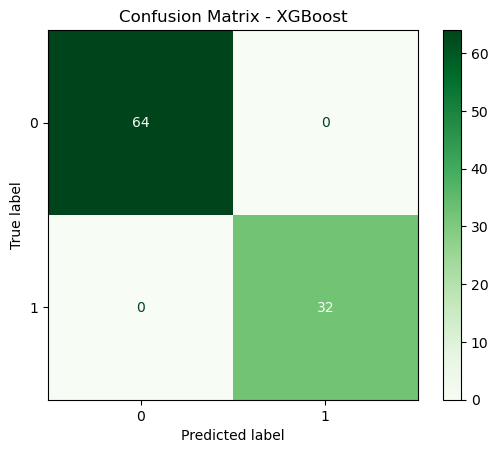

In [127]:
# ✅ Confusion Matrix for XGBoost
y_pred_xgb = xgb_best.predict(x_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix - XGBoost")
plt.show()


/var/folders/qc/8f0djz2945q4282f0l_gt7r80000gn/T/ipykernel_10079/775195015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_xgb_sorted, y=importances_xgb_sorted.index, palette='crest')


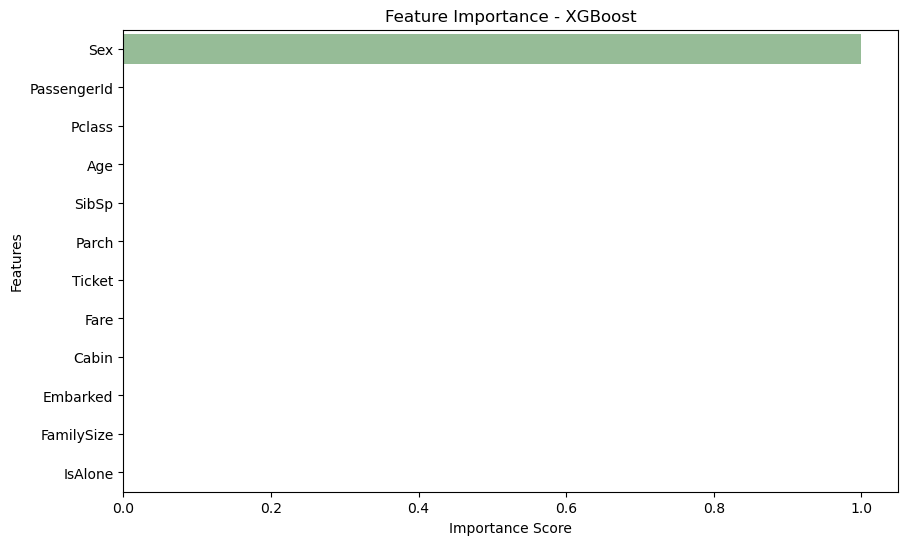

In [128]:
importances_xgb = pd.Series(xgb_best.feature_importances_, index=x_train.columns)
importances_xgb_sorted = importances_xgb.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_xgb_sorted, y=importances_xgb_sorted.index, palette='crest')
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### 2. Gradient Decent

In [100]:
from sklearn.ensemble import GradientBoostingClassifier

In [101]:
# 1. Default model
gb_default = GradientBoostingClassifier()
gb_default.fit(x_train, y_train)
gb_default_pred = gb_default.predict(x_test)
gb_default_acc = accuracy_score(y_test, gb_default_pred)

In [102]:
# 2. Tuning
gb = GradientBoostingClassifier()
gb_params = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb_grid = GridSearchCV(gb, gb_params, cv=3, n_jobs=-1, verbose=1)
gb_grid.fit(x_train, y_train)
gb_best = gb_grid.best_estimator_
gb_tuned_pred = gb_best.predict(x_test)
gb_tuned_acc = accuracy_score(y_test, gb_tuned_pred)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [103]:
print("Gradient Boosting Accuracy (After Tuning):", gb_tuned_acc)
print("Best Parameters:", gb_grid.best_params_)

Gradient Boosting Accuracy (Before Tuning): 1.0
Gradient Boosting Accuracy (After Tuning): 1.0
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


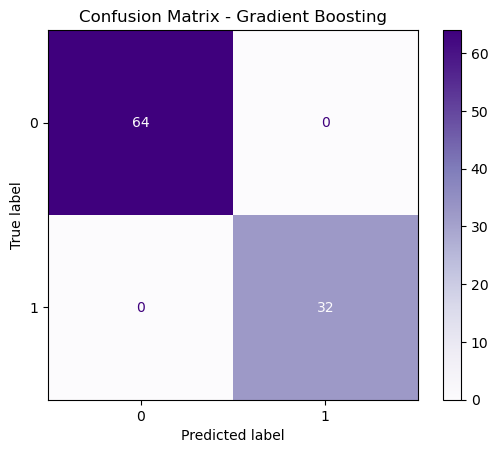

In [125]:
y_pred_gb = gb_best.predict(x_test)
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

/var/folders/qc/8f0djz2945q4282f0l_gt7r80000gn/T/ipykernel_10079/2257016288.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_gb_sorted, y=importances_gb_sorted.index, palette='magma')


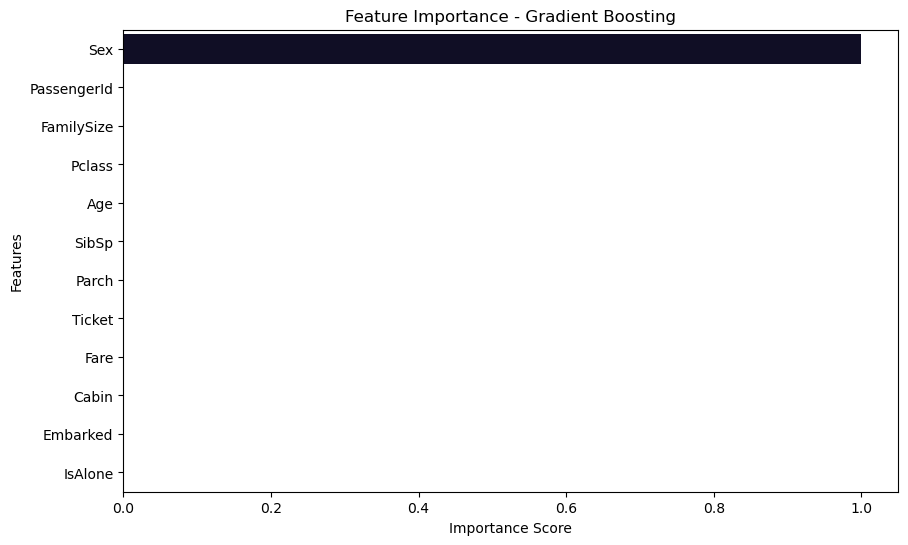

In [126]:
# ✅ Feature Importance
importances_gb = pd.Series(gb_best.feature_importances_, index=x_train.columns)
importances_gb_sorted = importances_gb.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_gb_sorted, y=importances_gb_sorted.index, palette='magma')
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### 3. Random Forest

In [110]:
from sklearn.ensemble import RandomForestClassifier

In [111]:
# 1. Default
rf_default = RandomForestClassifier()
rf_default.fit(x_train, y_train)
rf_default_pred = rf_default.predict(x_test)
rf_default_acc = accuracy_score(y_test, rf_default_pred)

In [112]:
print("Random Forest Accuracy (Before Tuning):", rf_default_acc)

Random Forest Accuracy (Before Tuning): 1.0


In [113]:
# 2. Tuning
rf = RandomForestClassifier()
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf, rf_params, cv=3, n_jobs=-1, verbose=1)
rf_grid.fit(x_train, y_train)
rf_best = rf_grid.best_estimator_
rf_tuned_pred = rf_best.predict(x_test)
rf_tuned_acc = accuracy_score(y_test, rf_tuned_pred)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [115]:
print("Random Forest Accuracy (After Tuning):", rf_tuned_acc)
print("Best Parameters:", rf_grid.best_params_)


Random Forest Accuracy (After Tuning): 1.0
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


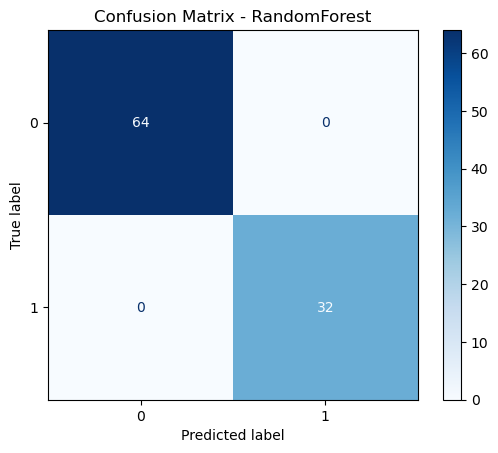

In [120]:
# ✅ 1. Confusion Matrix
y_pred_rf = rf_best.predict(x_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - RandomForest")
plt.show()

/var/folders/qc/8f0djz2945q4282f0l_gt7r80000gn/T/ipykernel_10079/1769339191.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_sorted, y=importances_sorted.index, palette='viridis')


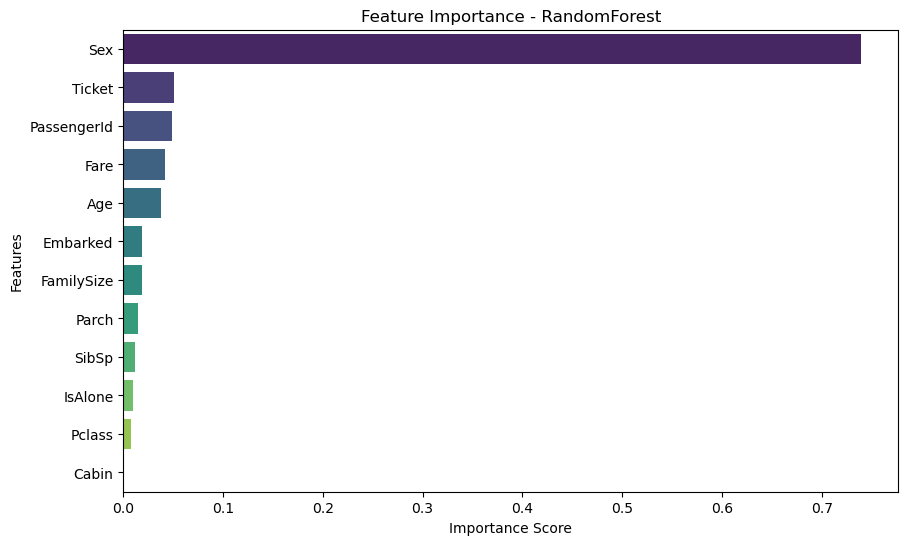

In [122]:
# ✅ 2. Feature Importance
importances = pd.Series(rf_best.feature_importances_, index=x_train.columns)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_sorted, y=importances_sorted.index, palette='viridis')
plt.title("Feature Importance - RandomForest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show();

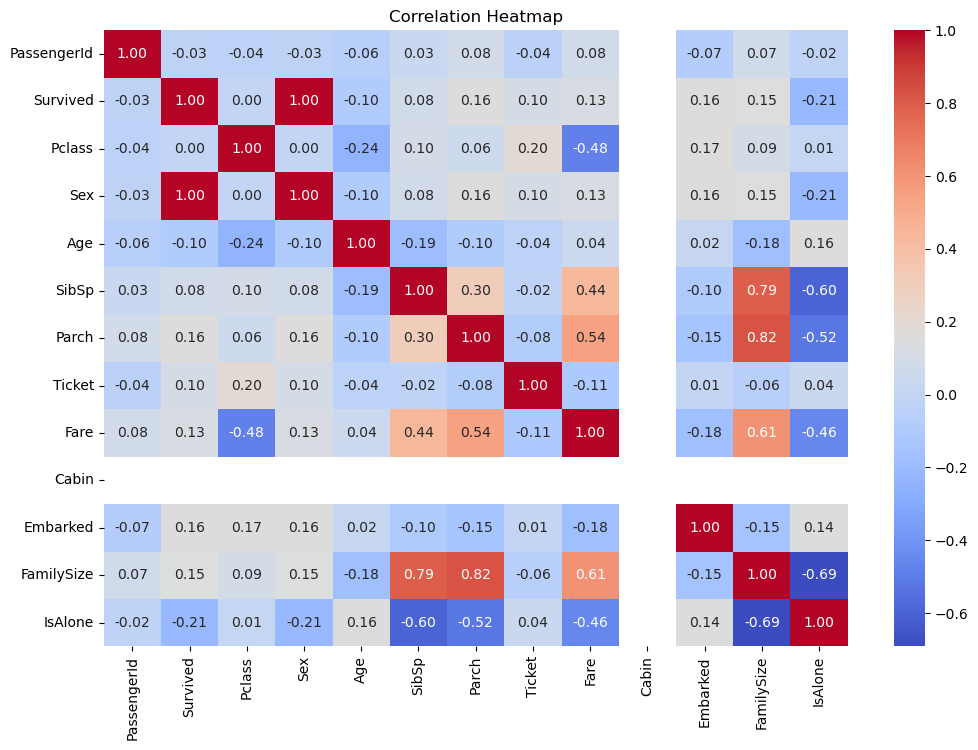

In [123]:
# ✅ 3. Heatmap of Feature Correlation (on whole dataset)
# Make sure to use the full dataset `df`
corr_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()